In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split 

# Supressing the warning messages
import warnings
warnings.filterwarnings('ignore')


In [2]:
df = pd.read_csv('energy_dataset.csv', parse_dates=['time'], date_parser=lambda x: pd.to_datetime(x).tz_convert('Europe/Paris'))

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 25 columns):
 #   Column                                       Non-Null Count  Dtype                       
---  ------                                       --------------  -----                       
 0   time                                         35064 non-null  datetime64[ns, Europe/Paris]
 1   generation_biomass                           35045 non-null  float64                     
 2   generation_fossil_brown_coal_lignite         35046 non-null  float64                     
 3   generation_fossil_coal-derived_gas           35046 non-null  float64                     
 4   generation_fossil_gas                        35046 non-null  float64                     
 5   generation_fossil_hard_coal                  35046 non-null  float64                     
 6   generation_fossil_oil                        35045 non-null  float64                     
 7   generation_fossil_oil_shale    

In [3]:
dfw = pd.read_csv('weather.csv', parse_dates=['time'], date_parser=lambda x: pd.to_datetime(x).tz_convert('Europe/Paris'))

dfw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype                       
---  ------       --------------  -----                       
 0   time         35064 non-null  datetime64[ns, Europe/Paris]
 1   temperature  35064 non-null  float64                     
 2   pressure     35064 non-null  float64                     
 3   humidity     35064 non-null  float64                     
 4   wind_speed   35064 non-null  float64                     
dtypes: datetime64[ns, Europe/Paris](1), float64(4)
memory usage: 1.3 MB


## Join two dataframes by common column: time

In [4]:
df = pd.merge(df, dfw, on='time', how='inner')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 29 columns):
 #   Column                                       Non-Null Count  Dtype                       
---  ------                                       --------------  -----                       
 0   time                                         35064 non-null  datetime64[ns, Europe/Paris]
 1   generation_biomass                           35045 non-null  float64                     
 2   generation_fossil_brown_coal_lignite         35046 non-null  float64                     
 3   generation_fossil_coal-derived_gas           35046 non-null  float64                     
 4   generation_fossil_gas                        35046 non-null  float64                     
 5   generation_fossil_hard_coal                  35046 non-null  float64                     
 6   generation_fossil_oil                        35045 non-null  float64                     
 7   generation_fossil_oil_shale    

In [5]:
# Alter name of goal attribute for price (easy to handle)

df.rename(columns={'price_day_ahead': 'price'}, inplace=True)

# Move price to the last column: more efficient method
column_to_move = df.pop('price')
df['price'] = column_to_move

In [6]:
# Removing duplicate rows if any

print('Shape before deleting duplicate rows:', df.shape)
shape_before=df.shape

df = df.drop_duplicates()
shape_after=df.shape

# Calculate the percentage of duplicates removed
perc_duplicates = round(((shape_before[0] - shape_after[0]) / shape_before[0]) * 100,1)

print('Shape after deleting duplicate rows:', df.shape)
print('Percentage of duplicate rows:',perc_duplicates,'%')

Shape before deleting duplicate rows: (35064, 29)
Shape after deleting duplicate rows: (35064, 29)
Percentage of duplicate rows: 0.0 %


In [7]:
# Set 'time' as the index
df.set_index('time', inplace=True)

# Verify the index
print("Index start:", df.index[0])

Index start: 2015-01-01 00:00:00+01:00


In [8]:
df.index.freq = 'H'

print(f"Index frequency: {df.index.freq}")

# Get the first value of the index
first_value = df.index[0]

# Get the last value of the index
last_value = df.index[-1]

# Print the results
print(f"First index value: {df.index[0]}")
print(f"Last index value: {df.index[-1]}")


Index frequency: <Hour>
First index value: 2015-01-01 00:00:00+01:00
Last index value: 2018-12-31 23:00:00+01:00


In [9]:
numericFeatures = list(df.select_dtypes(include='number').columns)
categFeatures = list(set(df.columns) - set(numericFeatures))

print(len(numericFeatures)," Numeric Features: ",numericFeatures)
print(len(categFeatures)," Categorical Features: ",categFeatures)

28  Numeric Features:  ['generation_biomass', 'generation_fossil_brown_coal_lignite', 'generation_fossil_coal-derived_gas', 'generation_fossil_gas', 'generation_fossil_hard_coal', 'generation_fossil_oil', 'generation_fossil_oil_shale', 'generation_fossil_peat', 'generation_geothermal', 'generation_hydro_pumped_storage_aggregated', 'generation_hydro_pumped_storage_consumption', 'generation_hydro_run-of-river_and_poundage', 'generation_hydro_water_reservoir', 'generation_marine', 'generation_nuclear', 'generation_other', 'generation_other_renewable', 'generation_solar', 'generation_waste', 'generation_wind_offshore', 'generation_wind_onshore', 'forecast_wind_offshore_eday_ahead', 'total_load_actual', 'temperature', 'pressure', 'humidity', 'wind_speed', 'price']
0  Categorical Features:  []


##  Check data types, distinct values, missing values, and outliers
### Function to detect outliers using the IQR method

In [10]:
def calculate_outliers(series):
    # Calculate the first and third quartiles
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    
    # Define outlier boundaries
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Calculate outliers
    outliers = series[(series < lower_bound) | (series > upper_bound)]
    return len(outliers), len(outliers) / len(series) * 100  # return number and percentage


In [11]:
def check_data(data, numFeats):

    data_info = pd.DataFrame({
        'Data Type': data.dtypes,
        'Unique Values': data.nunique(),
        'Missing Values': data.isnull().sum(),
        '% Missing': (data.isnull().sum() / data.shape[0]).mul(100).round(1).astype(str) + '%',
    })

    # Initialize lists to store the outlier results
    outlier_counts = []
    outlier_percentages = []

    # Calculate outliers for each numerical column
    for column in data.columns:
        if column in numFeats:
            outlier_count, outlier_percentage = calculate_outliers(data[column])
            outlier_counts.append(outlier_count)
            outlier_percentages.append(round(outlier_percentage, 1))
        else:
             outlier_counts.append(" --- ")
             outlier_percentages.append(" --- ")
        
    # Add the outlier information to the data_info DataFrame
    data_info['Outlier Count'] = outlier_counts
    data_info['% Outliers'] = outlier_percentages

    return data_info

In [12]:
df_info =  check_data(df, numericFeatures)
df_info

,Data Type,Unique Values,Missing Values,% Missing,Outlier Count,% Outliers
generation_biomass,float64,423,19,0.1%,87,0.2
generation_fossil_brown_coal_lignite,float64,956,18,0.1%,0,0.0
generation_fossil_coal-derived_gas,float64,1,18,0.1%,0,0.0
generation_fossil_gas,float64,8297,18,0.1%,2185,6.2
generation_fossil_hard_coal,float64,7266,18,0.1%,0,0.0
generation_fossil_oil,float64,321,19,0.1%,246,0.7
generation_fossil_oil_shale,float64,1,18,0.1%,0,0.0
generation_fossil_peat,float64,1,18,0.1%,0,0.0
generation_geothermal,float64,1,18,0.1%,0,0.0
generation_hydro_pumped_storage_aggregated,float64,0,35064,100.0%,0,0.0


### Drop Columns with only one value or 100% missing values 

In [13]:
columns_toRemove = df_info[(df_info['Unique Values'] == 1) | (df_info['Unique Values'] == 0) ].index 

print(f"{len(columns_toRemove)} columns that will be removed:\n {columns_toRemove}\n")

print('Shape before deleting columns:', df.shape)
shape_before=df.shape

df.drop(columns=columns_toRemove, axis=1, inplace=True)

shape_after=df.shape

# Calculate the percentage of columns removed
perc_colsrem = round(((shape_before[1] - shape_after[1]) / shape_before[1]) * 100,1)

print('Shape after deleting columns:', df.shape)
print(f"{len(columns_toRemove)} columns removed ({perc_colsrem}%)")


8 columns that will be removed:
 Index(['generation_fossil_coal-derived_gas', 'generation_fossil_oil_shale',
       'generation_fossil_peat', 'generation_geothermal',
       'generation_hydro_pumped_storage_aggregated', 'generation_marine',
       'generation_wind_offshore', 'forecast_wind_offshore_eday_ahead'],
      dtype='object')

Shape before deleting columns: (35064, 28)
Shape after deleting columns: (35064, 20)
8 columns removed (28.6%)


In [14]:
# Check again dataframe

# Clean column names
df.columns = (
    df.columns
    .str.lower()
    .str.replace('generation_', 'gen_')
    .str.replace(' ', '_')
    .str.replace('/', '_', regex=False)
)

numericFeatures = list(df.select_dtypes(include='number').columns)

df_info = check_data(df, numericFeatures)
df_info

,Data Type,Unique Values,Missing Values,% Missing,Outlier Count,% Outliers
gen_biomass,float64,423,19,0.1%,87,0.2
gen_fossil_brown_coal_lignite,float64,956,18,0.1%,0,0.0
gen_fossil_gas,float64,8297,18,0.1%,2185,6.2
gen_fossil_hard_coal,float64,7266,18,0.1%,0,0.0
gen_fossil_oil,float64,321,19,0.1%,246,0.7
gen_hydro_pumped_storage_consumption,float64,3311,19,0.1%,3762,10.7
gen_hydro_run-of-river_and_poundage,float64,1684,19,0.1%,0,0.0
gen_hydro_water_reservoir,float64,7029,18,0.1%,343,1.0
gen_nuclear,float64,2388,17,0.0%,74,0.2
gen_other,float64,103,18,0.1%,1267,3.6


## Fill missing values

Column	% Outliers:
- generation fossil gas	6.2%
- generation hydro pumped storage 10.7%
- generation other	3.6%
- Others (e.g., wind, biomass, oil)	<1%–3%

Forward-fill or backward-fill would blindly propagate these potentially anomalous values into missing points.

Linear interpolation, on the other hand:
- Smooths values using both previous and next known points,
- Reduces the chance of copying spikes or anomalies into new positions,
- Preserves time continuity and seasonality much better, especially for volatile predictors like wind and solar.

For time series with **seasonal patterns** or long missing blocks, more sophisticated imputation (e.g., STL, Kalman filters) may be needed.
But in this case — where data is dense, mostly clean, and only lightly missing — **linear interpolation** offers a balanced, non-distorting solution.


In [15]:
# Convert index to timezone-naive (required for time-based interpolation)
df.index = df.index.tz_localize(None)

# Apply time-based linear interpolation
df.interpolate(method='time', inplace=True)

# Confirm that all missing values were filled
missing_count = df.isna().sum().sum()
print(f"Total missing values remaining: {missing_count}")


Total missing values remaining: 0


In [16]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
gen_biomass,35064.0,383.531343,85.346266,0.000,333.000000,367.0000,433.0000,592.000
gen_fossil_brown_coal_lignite,35064.0,448.094570,354.618269,0.000,0.000000,509.0000,757.0000,999.000
gen_fossil_gas,35064.0,5622.700647,2201.510984,0.000,4126.000000,4969.5000,6429.0000,20034.000
gen_fossil_hard_coal,35064.0,4256.531271,1961.988937,0.000,2527.000000,4475.0000,5839.0000,8359.000
gen_fossil_oil,35064.0,298.342417,52.519927,0.000,263.000000,300.0000,330.0000,449.000
gen_hydro_pumped_storage_consumption,35064.0,475.582706,792.312704,0.000,0.000000,68.0000,616.0000,4523.000
gen_hydro_run-of-river_and_poundage,35064.0,972.201902,400.712304,0.000,637.000000,906.0000,1250.0000,2000.000
gen_hydro_water_reservoir,35064.0,2605.534123,1835.175078,0.000,1078.000000,2165.0000,3758.0000,9728.000
gen_nuclear,35064.0,6263.483430,840.272333,0.000,5759.000000,6564.0000,7025.0000,7117.000
gen_other,35064.0,60.226030,20.238792,0.000,53.000000,57.0000,80.0000,106.000


## Correlation Analysis
### With goall attribute: price

gen_fossil_hard_coal                    0.671786
gen_fossil_gas                          0.640907
gen_fossil_brown_coal_lignite           0.568159
total_load_actual                       0.474273
gen_other_renewable                     0.427838
gen_waste                               0.368001
gen_fossil_oil                          0.292828
gen_biomass                             0.109238
pressure                                0.084098
temperature                             0.071707
gen_solar                               0.058107
gen_other                               0.043960
gen_hydro_water_reservoir              -0.017366
gen_nuclear                            -0.043345
humidity                               -0.043658
wind_speed                             -0.117201
gen_hydro_run-of-river_and_poundage    -0.294524
gen_wind_onshore                       -0.424892
gen_hydro_pumped_storage_consumption   -0.600574
Name: price, dtype: float64


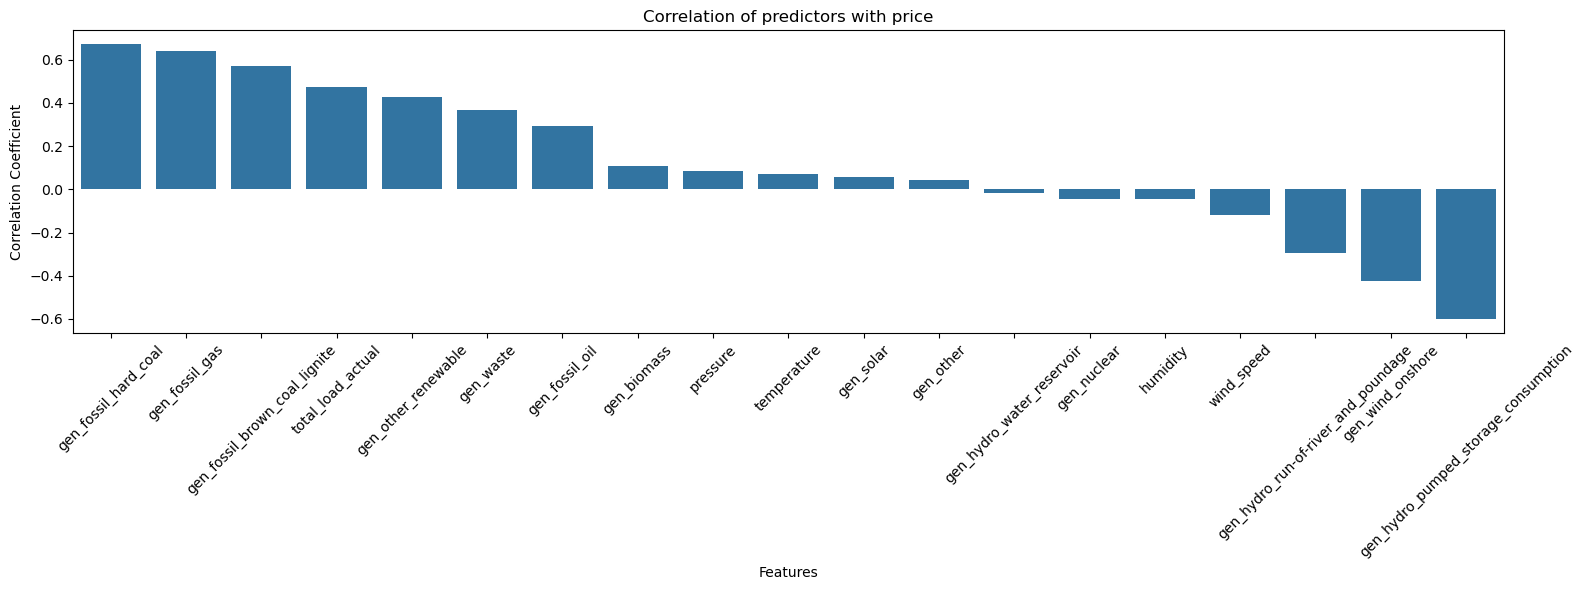

In [17]:
# Compute the correlation matrix
numeric_features = df.select_dtypes(include=['int64', 'float64'])

corr_matrix = numeric_features.corr()

# Select the correlations with 'strength' and sort them
price_correls = corr_matrix['price'].sort_values(ascending=False)

# Print the sorted correlations
price_correls = price_correls[1:]
print(price_correls)

# Plotting
plt.figure(figsize=(16, 6))
sns.barplot(x=price_correls.index, y=price_correls.values)

plt.title('Correlation of predictors with price')
plt.xlabel('Features')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=45)  # Rotate feature names for better readability
plt.tight_layout()
plt.show()

**Fossil** generation sources, such as gas and coal, represented by the **variables gen_fossil_hard_coal**, **gen_fossil_gas**, and **gen_fossil_brown_coal_lignite**, show a high positive correlation with the target price variable, indicating that energy from fossil sources is associated with a higher price. 

On the contrary, the **renewable** sources, namely **gen_hydro_pumped_storage_consumption**, **gen_wind_onshore**, and **gen_hydro_run-of-river_and_poundage** exhibit a high negative correlation with the price variable, suggesting that an increase in renewable production contributes to a reduction in prices in the day-ahead market.

In general, the results confirm that the price of electricity is mainly influenced by demand and the generation mix, highlighting the moderating role of renewable sources and hydro storage. This analysis supports the selection of variables and the definition of modelling strategies adopted in the subsequent phases of the project.

### Select Relevant Exogenous Variables

In [18]:
important_exogs = ['total_load_actual',
                   'gen_wind_onshore',
                   'gen_solar',
                   'gen_fossil_gas',
                   'gen_hydro_pumped_storage_consumption',
                   'humidity',
                   'temperature', 'price']

corr_matrix = df[important_exogs].corr()

price_correls = corr_matrix['price'].abs().sort_values(ascending=False)
price_correls = price_correls[1:]
print("\nAbsolute correlations with price:")
print(price_correls)



Absolute correlations with price:
gen_fossil_gas                          0.640907
gen_hydro_pumped_storage_consumption    0.600574
total_load_actual                       0.474273
gen_wind_onshore                        0.424892
temperature                             0.071707
gen_solar                               0.058107
humidity                                0.043658
Name: price, dtype: float64


### Save data pre-processed

In [19]:
# Ensure the index is the original index in the correct timezone (Europe/Paris for +01:00)
dfaux = pd.read_csv('energy_dataset.csv', parse_dates=['time'], date_parser=lambda x: pd.to_datetime(x).tz_convert('Europe/Paris'))

# Reset the index of the processed DataFrame
df = df.reset_index()

# Replace the 'time' column from df_original to ensure time column includes +01:00
df['time'] = dfaux['time']  

# Save to CSV
df.to_csv('energy_dataset_clean.csv', index=False)